# Unsupervised Anomaly Detection Report

In [1]:
from __future__ import annotations

import os
import sys
import urllib.error
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

repo_root = Path("..").resolve()
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from sklearn.base import clone  # noqa: E402

from src.data_loader import DataLoader  # noqa: E402
from src.datasets import CLUSTBENCH_DATASETS, ODDS_DATASETS  # noqa: E402
from src.ensemble import EnsembleDetector  # noqa: E402
from src.models import AnomalyDetectorFactory  # noqa: E402

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", palette="Set2")

plots_dir = Path("notebooks/plots")
plots_dir.mkdir(parents=True, exist_ok=True)


def _select_mlflow_tracking_uri() -> str:
    """Use the local MLflow server if it answers, otherwise fall back to the SQLite store."""
    candidate = "http://localhost:5000"
    probe_url = f"{candidate}/api/2.0/mlflow/experiments/search"
    try:
        req = urllib.request.Request(  # noqa: S310
            probe_url,
            data=b'{"max_results":1}',
            headers={"Content-Type": "application/json"},
            method="POST",
        )
        with urllib.request.urlopen(req, timeout=1.0) as resp:  # noqa: S310
            if resp.status == 200:
                return candidate
    except (urllib.error.URLError, urllib.error.HTTPError, OSError, TimeoutError):
        pass

    db_path = Path("mlflow.db").resolve()
    return f"sqlite:///{db_path}"


tracking_uri = _select_mlflow_tracking_uri()
mlflow.set_tracking_uri(tracking_uri)
print(f"MLflow tracking URI: {tracking_uri}")

MLflow tracking URI: sqlite:////Users/pawelflorek/PW/DS/sem1/DEV/p2/mlflow.db


## Section 1: Performance Evaluation



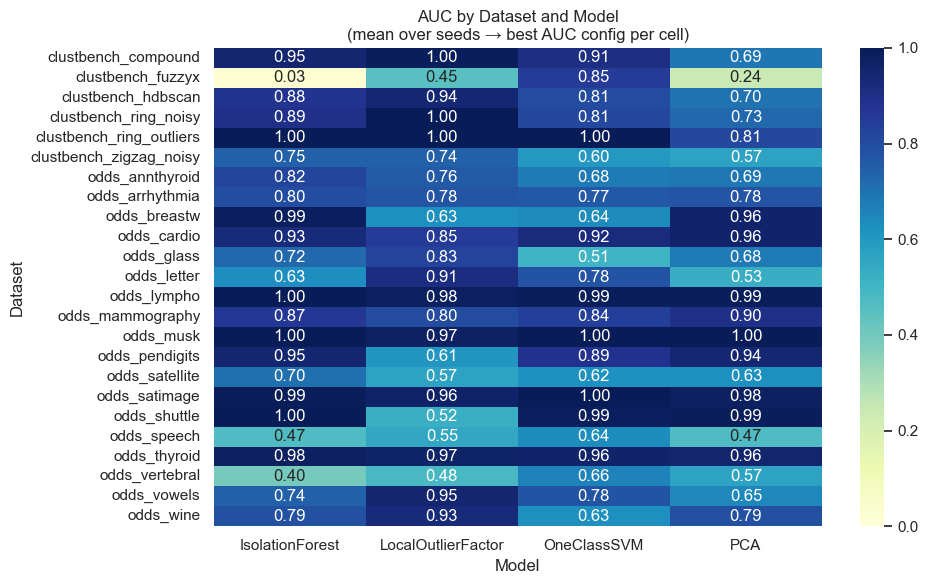

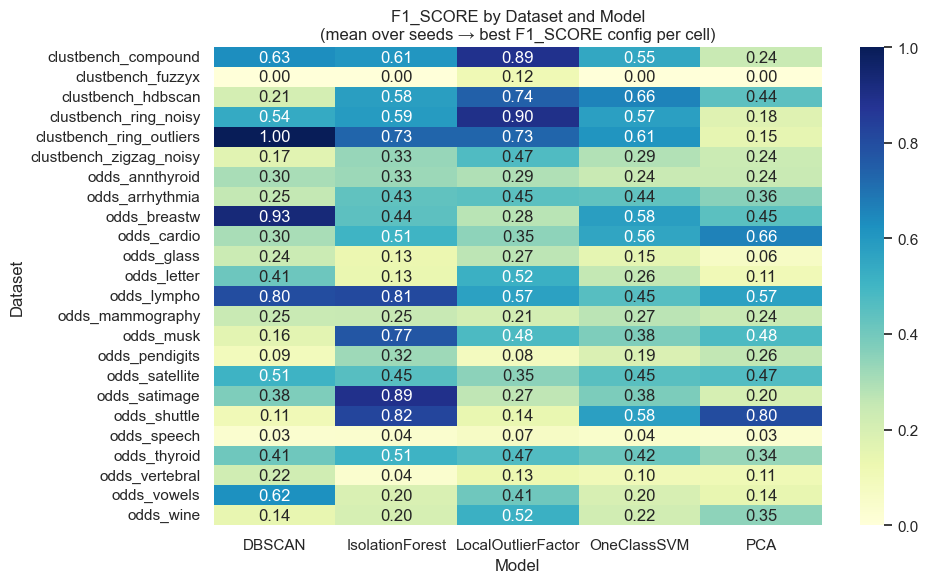

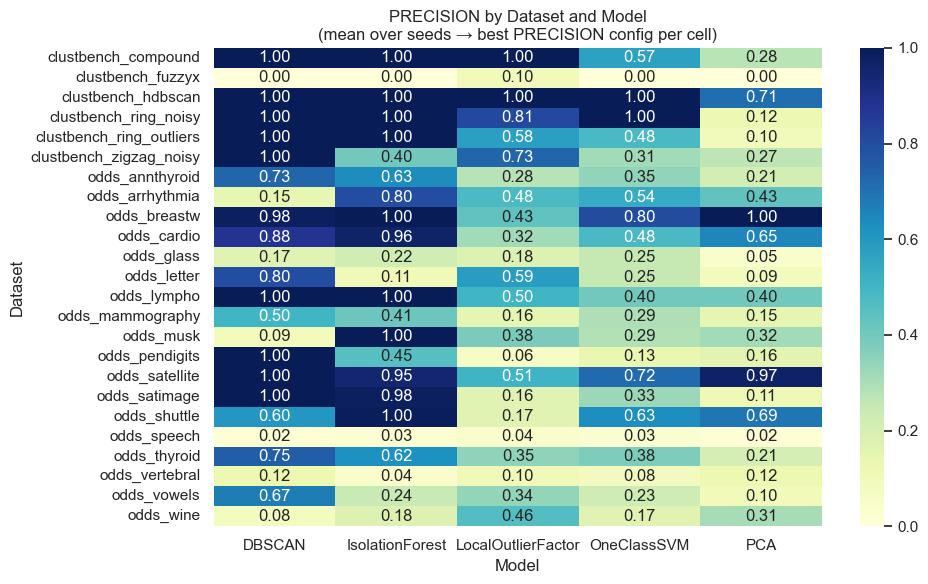

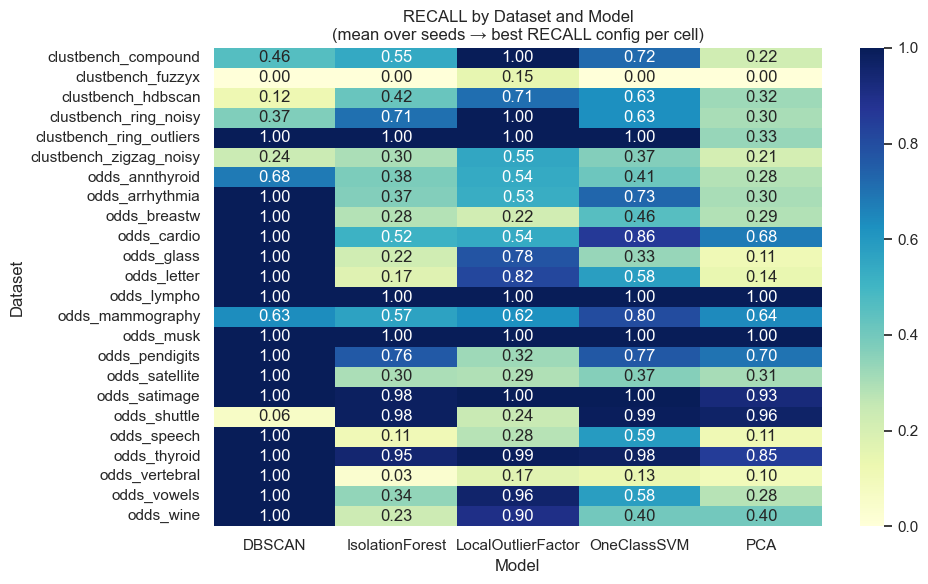

ClustBench leaderboard:


,model,f1_score,precision,recall,accuracy,auc
0,LocalOutlierFactor,0.640828,0.632994,0.679175,0.903964,0.849241
1,IsolationForest,0.473837,0.517227,0.487566,0.904471,0.748099
2,OneClassSVM,0.446480,0.397065,0.529192,0.877886,0.685958
3,DBSCAN,0.424950,0.688095,0.364430,0.880288,NaN
4,PCA,0.208073,0.245420,0.231292,0.836913,0.622602


ODDS leaderboard:


,model,f1_score,precision,recall,accuracy,auc
0,IsolationForest,0.403930,0.438890,0.446507,0.901513,0.818970
1,DBSCAN,0.342358,0.344261,0.664381,0.689285,NaN
2,OneClassSVM,0.327829,0.283699,0.517905,0.854421,0.728602
3,PCA,0.326545,0.332338,0.504994,0.879239,0.800126
4,LocalOutlierFactor,0.325063,0.283139,0.466754,0.864072,0.773292


In [2]:
from scipy.io import loadmat

experiment = mlflow.get_experiment_by_name("anomaly-detection")
if experiment is None:
    experiments = mlflow.search_experiments()
    experiment = experiments[0] if experiments else None

if experiment is None:
    raise RuntimeError("No MLflow experiment found. Start the MLflow server and rerun.")

runs = mlflow.search_runs([experiment.experiment_id])
if runs.empty:
    raise RuntimeError("No MLflow runs found for the selected experiment.")

df = runs.copy()
df["dataset"] = df.get("tags.dataset")
df["model_key"] = df.get("tags.model_factory_key")
df["family"] = df.get("tags.family")
df["f1_score"] = df.get("metrics.f1_score")
df["precision"] = df.get("metrics.precision")
df["recall"] = df.get("metrics.recall")
df["accuracy"] = df.get("metrics.accuracy")
df["auc"] = df.get("metrics.auc")

model_name_map = {
    "isolation_forest": "IsolationForest",
    "local_outlier_factor": "LocalOutlierFactor",
    "one_class_svm": "OneClassSVM",
    "dbscan": "DBSCAN",
    "pca": "PCA",
}
df["model"] = df["model_key"].map(model_name_map).fillna(df["model_key"])


def _build_odds_feature_dim_map() -> dict[str, int]:
    """Read #features from each ODDS `.mat` so plots stay aligned with `src/datasets.py`."""
    out: dict[str, int] = {}
    for cfg in ODDS_DATASETS:
        p = Path(cfg.data_path)
        if not p.is_file():
            continue
        m = loadmat(p)
        features = m.get("X")
        if features is None:
            continue
        out[cfg.name] = int(np.asarray(features).shape[1])
    return out


n_features_map = _build_odds_feature_dim_map()
df["dataset_group"] = np.where(df["dataset"].str.startswith("odds_"), "odds", "clustbench")
df["n_features"] = df["dataset"].map(n_features_map)
df.loc[df["dataset_group"] == "clustbench", "n_features"] = 2

SEED_PARAM = "params.random_state"
metric_cols = ["f1_score", "precision", "recall", "accuracy", "auc"]
param_cols_no_seed = [c for c in df.columns if c.startswith("params.") and c != SEED_PARAM]
group_cols = [
    "dataset",
    "dataset_group",
    "model_key",
    "model",
    "family",
    "n_features",
    *param_cols_no_seed,
]
df_seed_mean = (
    df.dropna(subset=["dataset", "model_key", "f1_score"])
    .groupby(group_cols, dropna=False, as_index=False)[metric_cols]
    .mean()
)

df_main = df_seed_mean[
    [
        "dataset",
        "dataset_group",
        "model_key",
        "model",
        "family",
        "f1_score",
        "precision",
        "recall",
        "accuracy",
        "auc",
        "n_features",
        *param_cols_no_seed,
    ]
].copy()

metrics_to_plot = ["auc", "f1_score", "precision", "recall"]
dataset_order = sorted(df_main.dataset.unique().tolist())

for metric in metrics_to_plot:
    best_per_dataset = (
        df_main.sort_values(metric, ascending=False)
        .groupby(["dataset", "model"], as_index=False)
        .head(1)
    )

    best_per_dataset_clean = best_per_dataset[best_per_dataset[metric].notna()]

    pivot = (
        best_per_dataset_clean.pivot(index="dataset", columns="model", values=metric)
        .fillna(0.0)
        .reindex(dataset_order)
    )
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0.0,
        vmax=1.0,
    )
    plt.title(
        f"{metric.upper()} by Dataset and Model\n"
        f"(mean over seeds → best {metric.upper()} config per cell)"
    )
    plt.xlabel("Model")
    plt.ylabel("Dataset")
    plt.tight_layout()
    plt.savefig(plots_dir / f"heatmap_{metric}.png", dpi=300)
    plt.show()


df_main_clustbench = df_main[df_main["dataset_group"] == "clustbench"]

leaderboard_clustbench = (
    (
        df_main_clustbench.sort_values("f1_score", ascending=False)
        .groupby(["dataset", "model"], as_index=False)
        .head(1)
    )
    .groupby("model", as_index=False)[["f1_score", "precision", "recall", "accuracy", "auc"]]
    .mean()
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

print("ClustBench leaderboard:")
display(leaderboard_clustbench)

df_main_odds = df_main[df_main["dataset_group"] == "odds"]

leaderboard_odds = (
    (
        df_main_odds.sort_values("f1_score", ascending=False)
        .groupby(["dataset", "model"], as_index=False)
        .head(1)
    )
    .groupby("model", as_index=False)[["f1_score", "precision", "recall", "accuracy", "auc"]]
    .mean()
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

print("ODDS leaderboard:")
display(leaderboard_odds)

best_per_dataset = (
    df_main.sort_values("f1_score", ascending=False)
    .groupby(["dataset", "model"], as_index=False)
    .head(1)
)

In [3]:
_per_dataset_winners = (
    best_per_dataset.sort_values("f1_score", ascending=False)
    .groupby("dataset", as_index=False)
    .head(1)
)
_winner_order = [
    "LocalOutlierFactor",
    "IsolationForest",
    "DBSCAN",
    "OneClassSVM",
    "PCA",
]
_winner_counts = (
    _per_dataset_winners["model"].value_counts().reindex(_winner_order, fill_value=0).astype(int)
)

print(
    "Per-dataset winners (highest F1 among the five families; "
    "mean over seeds → max over hyperparameter grid):"
)
display(
    _per_dataset_winners[["dataset", "dataset_group", "model", "f1_score"]]
    .sort_values("dataset")
    .reset_index(drop=True)
)
print("\nWinner counts (24 benchmarks = 18 ODDS + 6 ClustBench):")
for model, n in _winner_counts.items():
    print(f"  {model}: {n}")

Per-dataset winners (highest F1 among the five families; mean over seeds → max over hyperparameter grid):


,dataset,dataset_group,model,f1_score
0,clustbench_compound,clustbench,LocalOutlierFactor,0.888889
1,clustbench_fuzzyx,clustbench,LocalOutlierFactor,0.115152
2,clustbench_hdbscan,clustbench,LocalOutlierFactor,0.742798
3,clustbench_ring_noisy,clustbench,LocalOutlierFactor,0.895833
4,clustbench_ring_outliers,clustbench,DBSCAN,1.000000
5,clustbench_zigzag_noisy,clustbench,LocalOutlierFactor,0.470588
6,odds_annthyroid,odds,IsolationForest,0.325359
7,odds_arrhythmia,odds,LocalOutlierFactor,0.445860
8,odds_breastw,odds,DBSCAN,0.931507
9,odds_cardio,odds,PCA,0.662953



Winner counts (24 benchmarks = 18 ODDS + 6 ClustBench):
  LocalOutlierFactor: 10
  IsolationForest: 7
  DBSCAN: 5
  OneClassSVM: 1
  PCA: 1


## Section 2: Hyperparameter Analysis

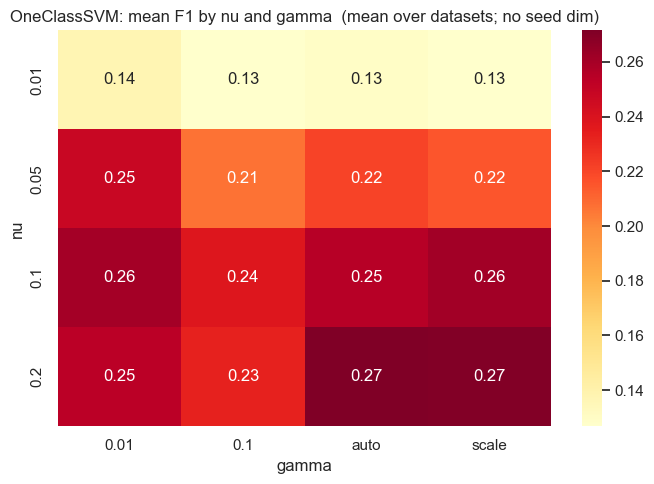

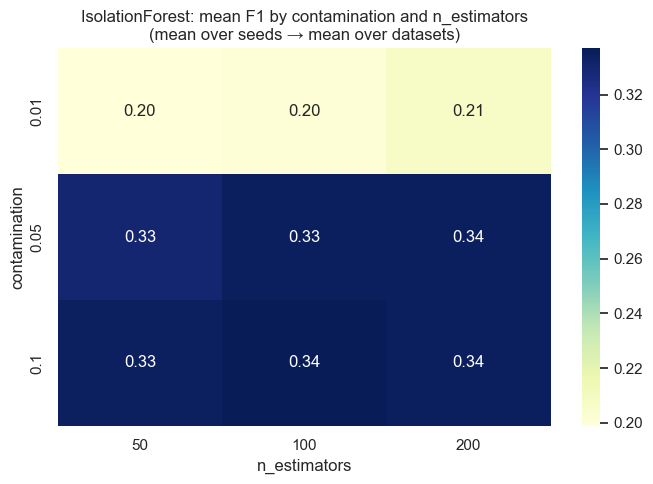

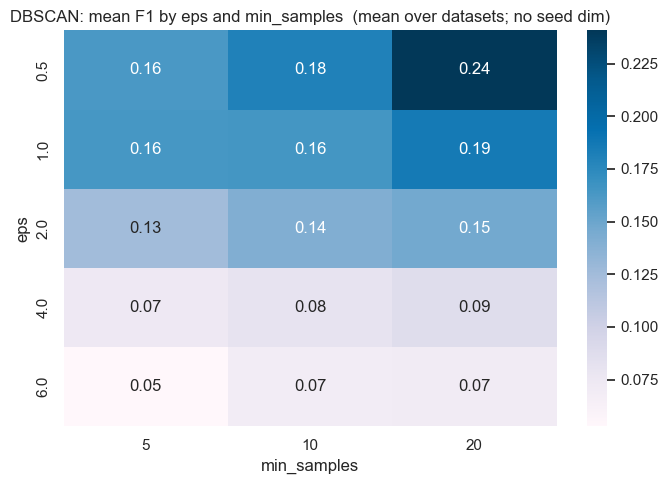

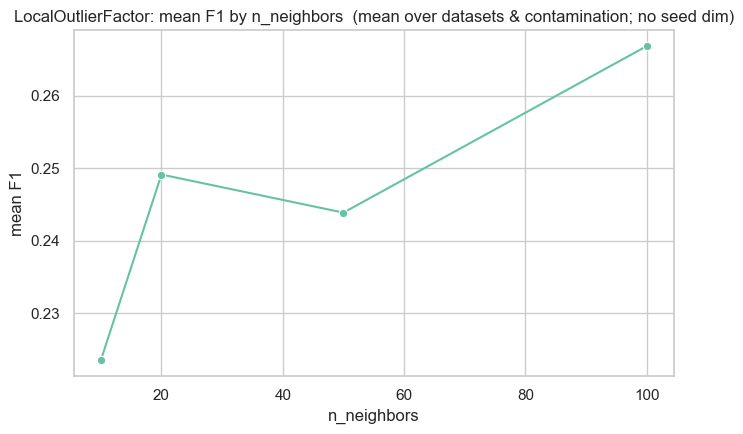

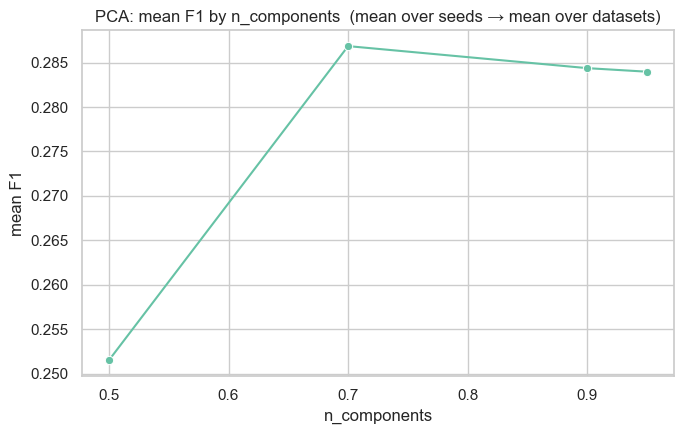

In [4]:
def _seed_mean(
    df_subset: pd.DataFrame,
    metric_col: str = "f1_score",
    seed_col: str = "params.random_state",
) -> pd.DataFrame:
    """Average ``metric_col`` across seeds, keeping one row per (dataset, params-without-seed).

    For models without a ``random_state`` parameter this is a no-op (each (dataset, params)
    already has a single row), so the downstream mean-aggregation receives the same data.
    """
    sub = df_subset.dropna(subset=[metric_col]).copy()
    param_cols = [c for c in sub.columns if c.startswith("params.") and c != seed_col]
    group_cols = ["dataset", *param_cols]
    return sub.groupby(group_cols, dropna=False, as_index=False)[metric_col].mean()


def _metric_pivot(df_subset: pd.DataFrame, index: str, columns: str, metric: str) -> pd.DataFrame:
    """Pivot on the seed-averaged frame and take mean over off-axis dimensions."""
    return (
        df_subset.pivot_table(index=index, columns=columns, values=metric, aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )


svm_df = _seed_mean(df[df["model_key"] == "one_class_svm"])
svm_df["nu"] = pd.to_numeric(svm_df.get("params.nu"), errors="coerce")
svm_df["gamma"] = svm_df.get("params.gamma")
svm_pivot = _metric_pivot(svm_df.dropna(subset=["nu", "gamma"]), "nu", "gamma", "f1_score")
plt.figure(figsize=(7, 5))
sns.heatmap(svm_pivot, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("OneClassSVM: mean F1 by nu and gamma  (mean over datasets; no seed dim)")
plt.tight_layout()
plt.savefig(plots_dir / "svm_nu_gamma.png", dpi=300)
plt.show()

if_df = _seed_mean(df[df["model_key"] == "isolation_forest"])
if_df["contamination"] = pd.to_numeric(if_df.get("params.contamination"), errors="coerce")
if_df["n_estimators"] = pd.to_numeric(if_df.get("params.n_estimators"), errors="coerce")
if_pivot = _metric_pivot(
    if_df.dropna(subset=["contamination", "n_estimators"]),
    "contamination",
    "n_estimators",
    "f1_score",
)
plt.figure(figsize=(7, 5))
sns.heatmap(if_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(
    "IsolationForest: mean F1 by contamination and n_estimators\n"
    "(mean over seeds → mean over datasets)"
)
plt.tight_layout()
plt.savefig(plots_dir / "if_contamination_estimators.png", dpi=300)
plt.show()

db_df = _seed_mean(df[df["model_key"] == "dbscan"])
db_df["eps"] = pd.to_numeric(db_df.get("params.eps"), errors="coerce")
db_df["min_samples"] = pd.to_numeric(db_df.get("params.min_samples"), errors="coerce")
db_pivot = _metric_pivot(
    db_df.dropna(subset=["eps", "min_samples"]), "eps", "min_samples", "f1_score"
)
plt.figure(figsize=(7, 5))
sns.heatmap(db_pivot, annot=True, fmt=".2f", cmap="PuBu")
plt.title("DBSCAN: mean F1 by eps and min_samples  (mean over datasets; no seed dim)")
plt.tight_layout()
plt.savefig(plots_dir / "dbscan_eps_min_samples.png", dpi=300)
plt.show()

lof_df = _seed_mean(df[df["model_key"] == "local_outlier_factor"])
lof_df["n_neighbors"] = pd.to_numeric(lof_df.get("params.n_neighbors"), errors="coerce")
lof_line = (
    lof_df.dropna(subset=["n_neighbors"]).groupby("n_neighbors", as_index=False)["f1_score"].mean()
)
plt.figure(figsize=(7, 4.5))
sns.lineplot(data=lof_line, x="n_neighbors", y="f1_score", marker="o")
plt.ylabel("mean F1")
plt.title(
    "LocalOutlierFactor: mean F1 by n_neighbors  (mean over datasets & contamination; no seed dim)"
)
plt.tight_layout()
plt.savefig(plots_dir / "lof_n_neighbors.png", dpi=300)
plt.show()

pca_df = _seed_mean(df[df["model_key"] == "pca"])
pca_df["n_components"] = pd.to_numeric(pca_df.get("params.n_components"), errors="coerce")
pca_line = (
    pca_df.dropna(subset=["n_components"])
    .groupby("n_components", as_index=False)["f1_score"]
    .mean()
)
plt.figure(figsize=(7, 4.5))
sns.lineplot(data=pca_line, x="n_components", y="f1_score", marker="o")
plt.ylabel("mean F1")
plt.title("PCA: mean F1 by n_components  (mean over seeds → mean over datasets)")
plt.tight_layout()
plt.savefig(plots_dir / "pca_n_components.png", dpi=300)
plt.show()

## Section 3: Robustness and Failure Case Analysis

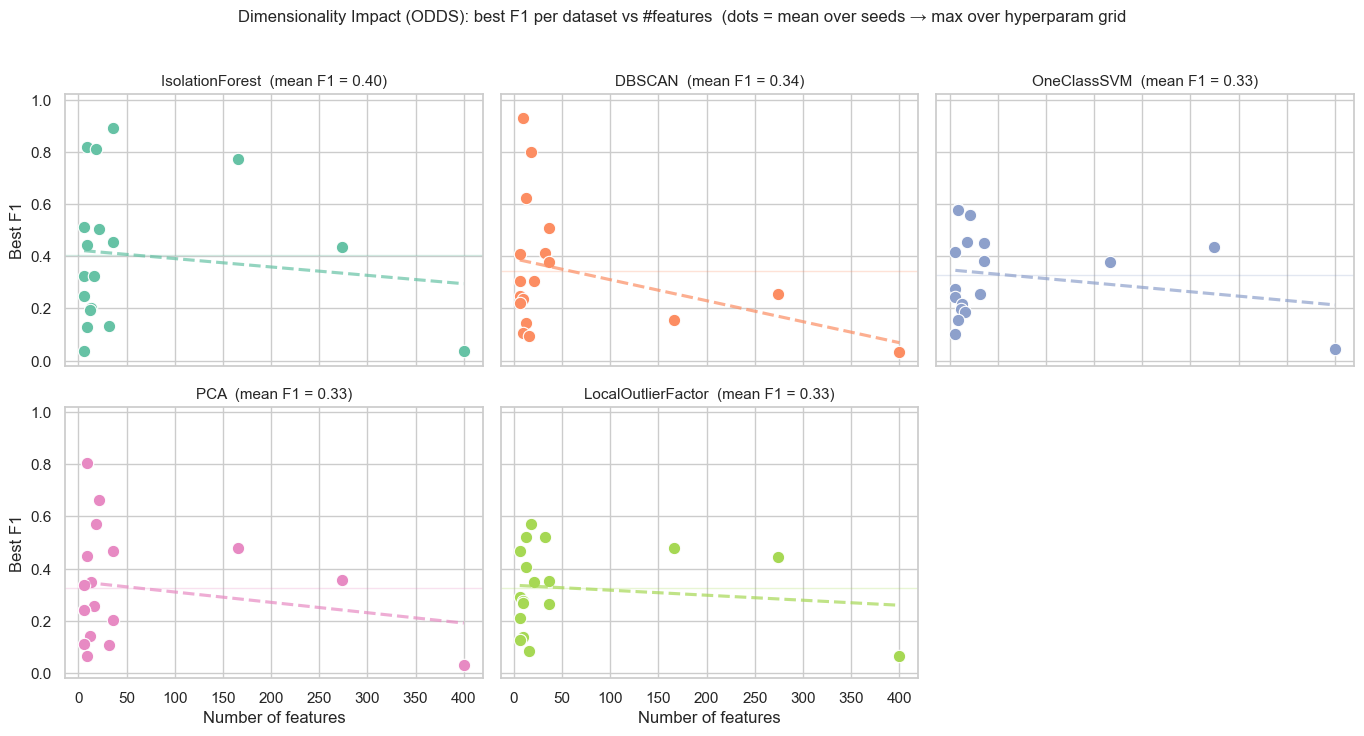

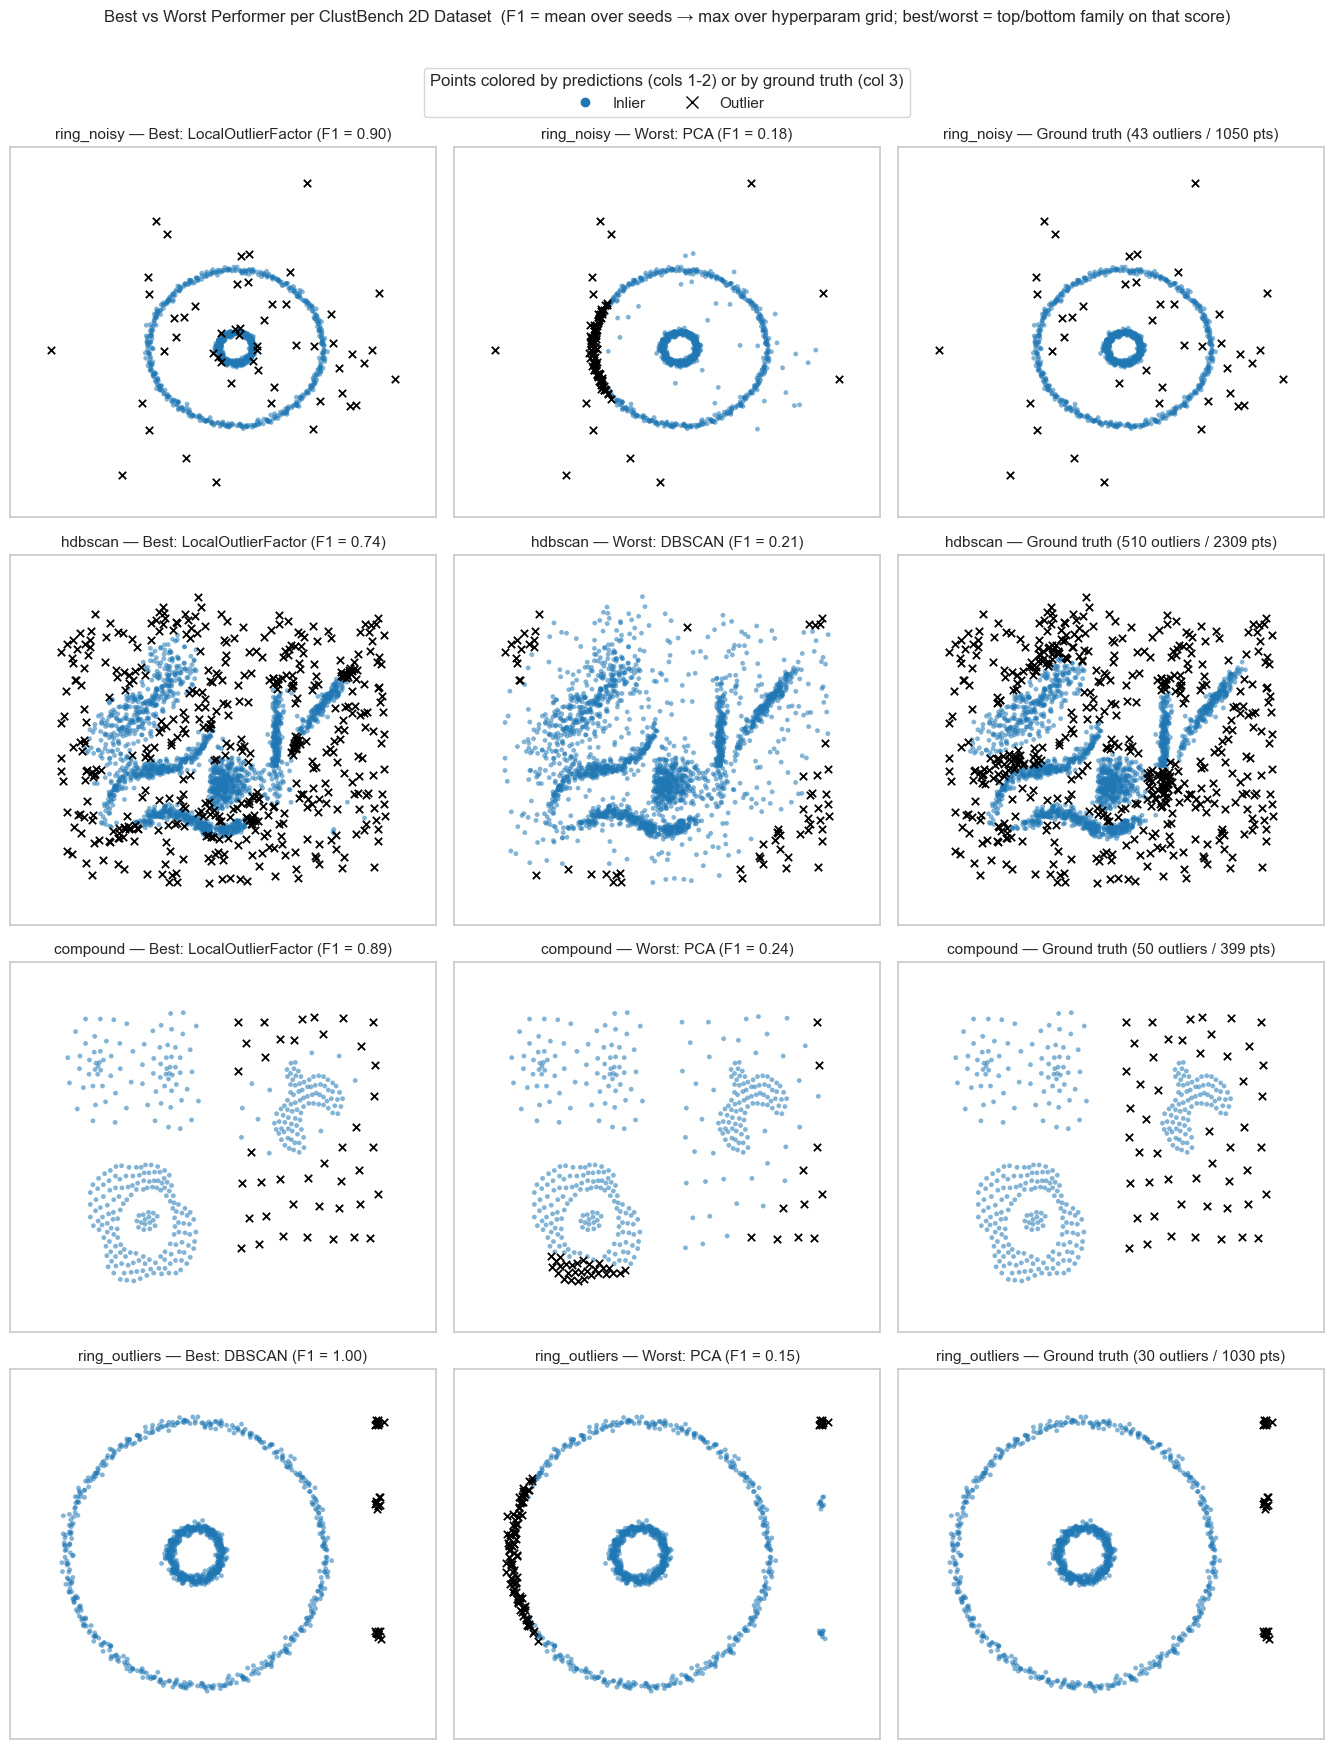

In [5]:
odds_dim = best_per_dataset[best_per_dataset["dataset_group"] == "odds"].copy()
odds_dim = odds_dim.dropna(subset=["n_features", "f1_score"])

model_order = (
    odds_dim.groupby("model")["f1_score"].mean().sort_values(ascending=False).index.tolist()
)
palette = dict(zip(model_order, sns.color_palette("Set2", n_colors=len(model_order)), strict=False))

n_models = len(model_order)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4.6 * n_cols, 3.6 * n_rows), sharex=True, sharey=True
)
axes = np.atleast_2d(axes).reshape(n_rows, n_cols)

x_min, x_max = odds_dim["n_features"].min(), odds_dim["n_features"].max()
x_pad = max(1.0, (x_max - x_min) * 0.05)

for idx, model_name in enumerate(model_order):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    subset = odds_dim[odds_dim["model"] == model_name]
    color = palette[model_name]

    sns.scatterplot(
        data=subset,
        x="n_features",
        y="f1_score",
        ax=ax,
        s=80,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        legend=False,
    )
    if len(subset) >= 2:
        sns.regplot(
            data=subset,
            x="n_features",
            y="f1_score",
            scatter=False,
            ax=ax,
            color=color,
            line_kws={"linestyle": "--", "alpha": 0.7},
            ci=None,
        )

    mean_f1 = subset["f1_score"].mean()
    ax.axhline(mean_f1, color=color, alpha=0.25, linewidth=1)
    ax.set_title(f"{model_name}  (mean F1 = {mean_f1:.2f})", fontsize=11)
    ax.set_xlabel("Number of features")
    ax.set_ylabel("Best F1")
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(-0.02, 1.02)

for idx in range(n_models, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].axis("off")

fig.suptitle(
    "Dimensionality Impact (ODDS): best F1 per dataset vs #features  "
    "(dots = mean over seeds → max over hyperparam grid",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.savefig(plots_dir / "dimensionality_impact.png", dpi=300, bbox_inches="tight")
plt.show()


def _normalize_labels(preds: np.ndarray) -> np.ndarray:
    labels = preds.astype(int)
    if set(np.unique(labels)) <= {0, 1}:
        return labels
    return np.where(labels == -1, 1, 0)


def _predict_outliers(model, features: np.ndarray) -> np.ndarray:
    if hasattr(model, "predict"):
        return _normalize_labels(model.predict(features))
    if hasattr(model, "labels_"):
        return _normalize_labels(model.labels_)
    return _normalize_labels(model.fit_predict(features))


def _axis_limits(features: np.ndarray) -> tuple[float, float, float, float]:
    pad_x = (features[:, 0].max() - features[:, 0].min()) * 0.05 + 0.5
    pad_y = (features[:, 1].max() - features[:, 1].min()) * 0.05 + 0.5
    return (
        features[:, 0].min() - pad_x,
        features[:, 0].max() + pad_x,
        features[:, 1].min() - pad_y,
        features[:, 1].max() + pad_y,
    )


def _scatter_by_label(features: np.ndarray, point_labels: np.ndarray, ax: plt.Axes) -> None:
    inliers = point_labels == 0
    outliers = point_labels == 1
    ax.scatter(
        features[inliers, 0],
        features[inliers, 1],
        s=12,
        c="#1f77b4",
        alpha=0.55,
        edgecolor="none",
    )
    ax.scatter(
        features[outliers, 0],
        features[outliers, 1],
        s=28,
        c="black",
        marker="x",
        linewidths=1.3,
    )


def plot_predictions(
    model,
    features: np.ndarray,
    ax: plt.Axes,
    title: str,
) -> None:
    """Plot the 2D dataset colored by the model's predicted labels."""
    x_min, x_max, y_min, y_max = _axis_limits(features)
    train_pred = _predict_outliers(model, features)
    _scatter_by_label(features, train_pred, ax)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])


def plot_ground_truth(features: np.ndarray, truth: np.ndarray, ax: plt.Axes, title: str) -> None:
    """Plot the 2D dataset colored by the ground-truth labels."""
    x_min, x_max, y_min, y_max = _axis_limits(features)
    _scatter_by_label(features, truth, ax)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])


def _row_to_params(row: pd.Series) -> dict[str, object]:
    """Extract typed hyperparameters from an MLflow runs row."""
    params: dict[str, object] = {}
    for col, val in row.items():
        if not isinstance(col, str) or not col.startswith("params."):
            continue
        if pd.isna(val):
            continue
        key = col.replace("params.", "")
        text = str(val)
        try:
            params[key] = int(text)
            continue
        except ValueError:
            pass
        try:
            params[key] = float(text)
            continue
        except ValueError:
            pass
        params[key] = text
    return params


clust_runs = df_seed_mean[df_seed_mean["dataset"].str.startswith("clustbench_")].copy()

best_per_model = (
    clust_runs.sort_values("f1_score", ascending=False)
    .groupby(["dataset", "model_key"], as_index=False)
    .head(1)
)

selected_clust_names = [
    "clustbench_compound",
    "clustbench_ring_outliers",
    "clustbench_ring_noisy",
    "clustbench_hdbscan",
]
available_in_runs = set(best_per_model["dataset"].unique())
selected_cfgs = [
    d for d in CLUSTBENCH_DATASETS if d.name in selected_clust_names and d.name in available_in_runs
]

loader = DataLoader()

fig, axes = plt.subplots(
    nrows=len(selected_cfgs),
    ncols=3,
    figsize=(13.5, 4.2 * len(selected_cfgs)),
)
axes = np.atleast_2d(axes)

for r, cfg in enumerate(selected_cfgs):
    loaded = loader.load_clustbench_files(
        cfg.data_path, cfg.labels_path, outlier_labels=cfg.outlier_labels
    )
    standardized = loader.standardize(loaded.features, loaded.labels)
    features = standardized.features
    truth = standardized.labels

    ds_runs = best_per_model[best_per_model["dataset"] == cfg.name].sort_values(
        "f1_score", ascending=False
    )
    selections = [("Best", ds_runs.iloc[0]), ("Worst", ds_runs.iloc[-1])]
    ds_short = cfg.name.replace("clustbench_", "")

    for c, (label, run_row) in enumerate(selections):
        spec = AnomalyDetectorFactory.create(run_row["model_key"])
        model = spec.model
        params = {k: v for k, v in _row_to_params(run_row).items() if k in model.get_params()}
        if params:
            model.set_params(**params)
        model.fit(features)

        model_disp = model_name_map.get(run_row["model_key"], run_row["model_key"])
        f1_value = float(run_row["f1_score"])
        title = f"{ds_short} — {label}: {model_disp} (F1 = {f1_value:.2f})"
        plot_predictions(model, features, axes[r, c], title)

    n_outliers = int((truth == 1).sum())
    n_inliers = int((truth == 0).sum())
    plot_ground_truth(
        features,
        truth,
        axes[r, 2],
        f"{ds_short} — Ground truth ({n_outliers} outliers / {n_inliers + n_outliers} pts)",
    )

handles = [
    plt.Line2D([], [], marker="o", color="#1f77b4", linestyle="", label="Inlier"),
    plt.Line2D([], [], marker="x", color="black", linestyle="", markersize=8, label="Outlier"),
]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01),
    title="Points colored by predictions (cols 1-2) or by ground truth (col 3)",
)
fig.suptitle(
    "Best vs Worst Performer per ClustBench 2D Dataset  "
    "(F1 = mean over seeds → max over hyperparam grid; "
    "best/worst = top/bottom family on that score)",
    y=1.04,
    fontsize=12,
)
plt.tight_layout()
plt.savefig(plots_dir / "best_vs_worst_clustbench.png", dpi=300, bbox_inches="tight")
plt.show()

Result stability per model  (lower std = more stable):


,seed_std(F1),hyperparam_std(F1),dataset_std(F1)
model,,,
PCA,0.0000,0.0230,0.2007
LocalOutlierFactor,0.0000,0.0886,0.1973
OneClassSVM,0.0000,0.0897,0.1411
IsolationForest,0.0124,0.1049,0.2236
DBSCAN,0.0000,0.1167,0.1740


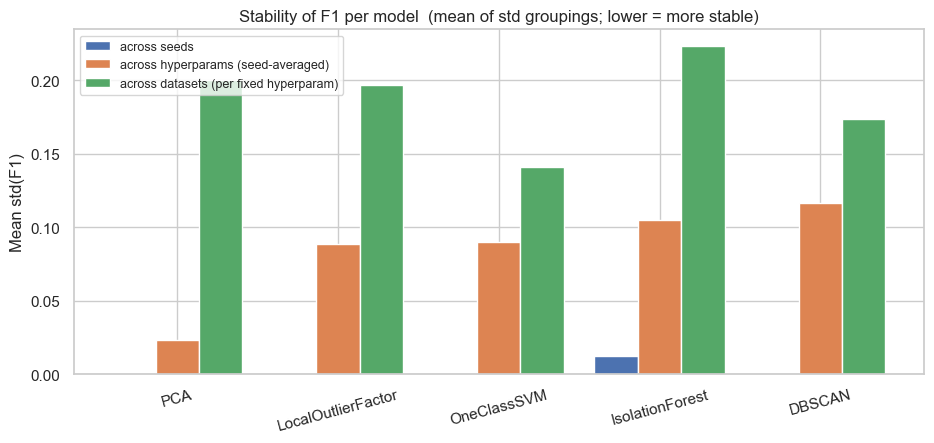

In [6]:
stability_records = []
for model_key in df["model_key"].dropna().unique():
    sub_all = df[df["model_key"] == model_key].dropna(subset=["f1_score"]).copy()
    if sub_all.empty:
        continue
    model_disp = model_name_map.get(model_key, model_key)

    param_cols = [
        c for c in sub_all.columns if c.startswith("params.") and c != "params.random_state"
    ]
    has_seed_axis = (
        "params.random_state" in sub_all.columns and sub_all["params.random_state"].notna().any()
    )

    if has_seed_axis and param_cols:
        seed_std_series = sub_all.groupby(["dataset", *param_cols], dropna=False)["f1_score"].std(
            ddof=0
        )
        seed_std = float(seed_std_series.dropna().mean())
    else:
        seed_std = 0.0

    sm = df_seed_mean[df_seed_mean["model_key"] == model_key]
    hp_std_series = sm.groupby("dataset")["f1_score"].std(ddof=0)
    hp_std = float(hp_std_series.dropna().mean())

    ds_std_series = sm.groupby([c for c in param_cols if c in sm.columns], dropna=False)[
        "f1_score"
    ].std(ddof=0)
    ds_std = float(ds_std_series.dropna().mean()) if not ds_std_series.empty else float("nan")

    stability_records.append(
        {
            "model": model_disp,
            "seed_std(F1)": seed_std,
            "hyperparam_std(F1)": hp_std,
            "dataset_std(F1)": ds_std,
        }
    )

stab_df = pd.DataFrame(stability_records).sort_values("hyperparam_std(F1)")
print("Result stability per model  (lower std = more stable):")
display(stab_df.set_index("model").round(4))

x = np.arange(len(stab_df))
width = 0.27
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.bar(x - width, stab_df["seed_std(F1)"], width=width, label="across seeds", color="#4c72b0")
ax.bar(
    x,
    stab_df["hyperparam_std(F1)"],
    width=width,
    label="across hyperparams (seed-averaged)",
    color="#dd8452",
)
ax.bar(
    x + width,
    stab_df["dataset_std(F1)"],
    width=width,
    label="across datasets (per fixed hyperparam)",
    color="#55a868",
)
ax.set_xticks(x)
ax.set_xticklabels(stab_df["model"], rotation=15)
ax.set_ylabel("Mean std(F1)")
ax.set_title("Stability of F1 per model  (mean of std groupings; lower = more stable)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(plots_dir / "stability_analysis.png", dpi=300)
plt.show()

ODDS dataset sizes: [('odds_wine', 129), ('odds_lympho', 148), ('odds_glass', 214), ('odds_vertebral', 240), ('odds_arrhythmia', 452), ('odds_breastw', 683), ('odds_vowels', 1456), ('odds_letter', 1600), ('odds_cardio', 1831), ('odds_musk', 3062), ('odds_speech', 3686), ('odds_thyroid', 3772), ('odds_satimage', 5803), ('odds_satellite', 6435), ('odds_pendigits', 6870), ('odds_annthyroid', 7200), ('odds_mammography', 11183), ('odds_shuttle', 49097)]


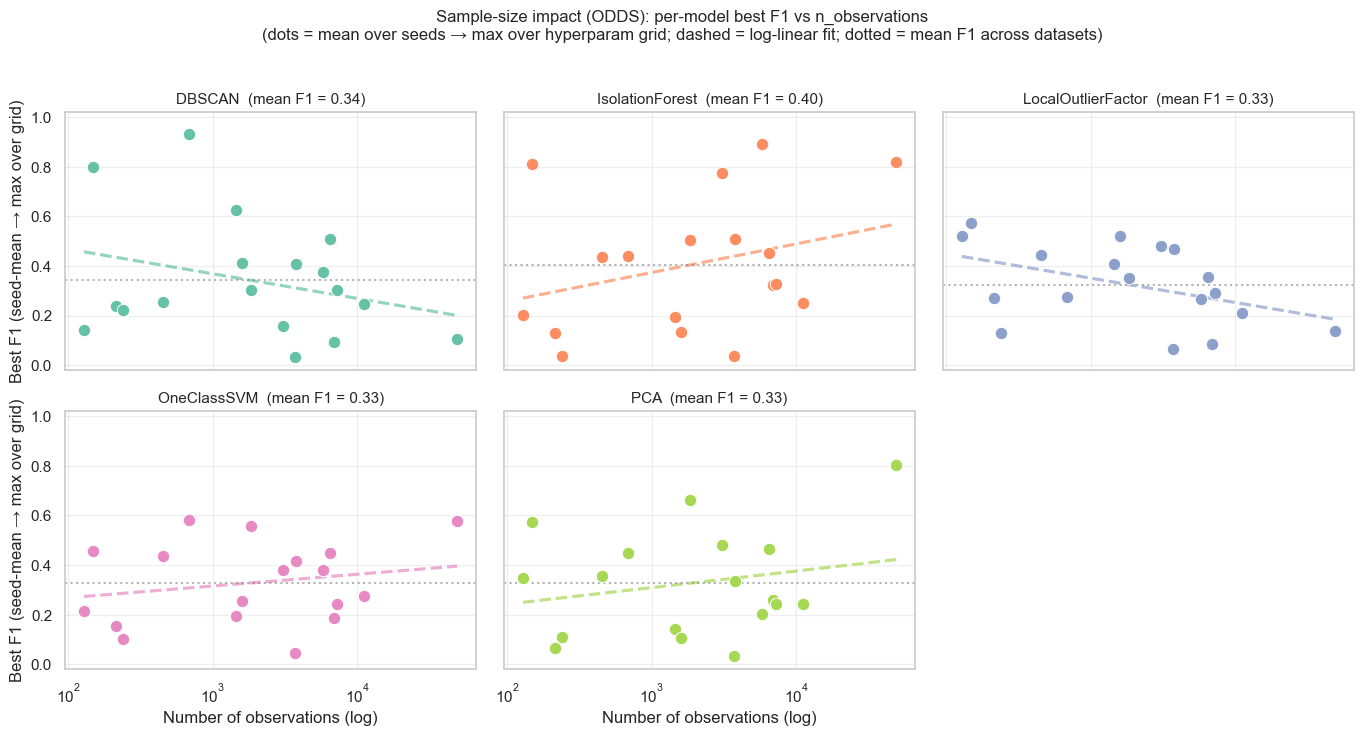


F1 sensitivity to dataset size (slope of F1 vs log10(n_samples)):


,slope_per_decade,mean_F1
model,,
IsolationForest,0.116,0.404
PCA,0.067,0.327
OneClassSVM,0.047,0.328
LocalOutlierFactor,-0.098,0.325
DBSCAN,-0.099,0.342


In [7]:
import contextlib

n_samples_map: dict[str, int] = {}
_loader_for_sizes = DataLoader()
for _cfg in ODDS_DATASETS:
    try:
        _d = _loader_for_sizes.load_odds_mat(_cfg.data_path)
        n_samples_map[_cfg.name] = len(_d.features)
    except Exception as exc:
        print(f"  skip {_cfg.name}: {exc}")

odds_obs = best_per_dataset[best_per_dataset["dataset_group"] == "odds"].copy()
odds_obs["n_samples"] = odds_obs["dataset"].map(n_samples_map)
odds_obs = odds_obs.dropna(subset=["n_samples"])

print(f"ODDS dataset sizes: {sorted(n_samples_map.items(), key=lambda kv: kv[1])}")

models_for_plot = sorted(odds_obs["model"].unique())
n_models = len(models_for_plot)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols)) if n_models else 1
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4.6 * n_cols, 3.6 * n_rows), sharex=True, sharey=True
)
axes = np.atleast_2d(axes)
palette = dict(zip(models_for_plot, sns.color_palette("Set2", n_colors=n_models), strict=False))

for idx, model_name in enumerate(models_for_plot):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]
    sub = odds_obs[odds_obs["model"] == model_name].sort_values("n_samples")
    color = palette[model_name]
    sns.scatterplot(data=sub, x="n_samples", y="f1_score", ax=ax, color=color, s=80, zorder=3)
    if len(sub) >= 2:
        with contextlib.suppress(Exception):
            sns.regplot(
                data=sub,
                x="n_samples",
                y="f1_score",
                scatter=False,
                ax=ax,
                color=color,
                ci=None,
                line_kws={"linestyle": "--", "alpha": 0.7},
                logx=True,
            )
    mean_f1 = sub["f1_score"].mean()
    ax.axhline(mean_f1, color="gray", linestyle=":", alpha=0.6)
    ax.set_title(f"{model_name}  (mean F1 = {mean_f1:.2f})", fontsize=11)
    ax.set_xlabel("Number of observations (log)")
    ax.set_ylabel("Best F1 (seed-mean → max over grid)")
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

for idx in range(n_models, n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r, c].axis("off")

fig.suptitle(
    "Sample-size impact (ODDS): per-model best F1 vs n_observations\n"
    "(dots = mean over seeds → max over hyperparam grid; "
    "dashed = log-linear fit; dotted = mean F1 across datasets)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.savefig(plots_dir / "n_observations_impact.png", dpi=300, bbox_inches="tight")
plt.show()

slopes = []
for model_name in models_for_plot:
    sub = odds_obs[odds_obs["model"] == model_name]
    if len(sub) >= 2:
        x_log = np.log10(sub["n_samples"].to_numpy())
        y = sub["f1_score"].to_numpy()
        slope = np.polyfit(x_log, y, 1)[0]
        slopes.append({"model": model_name, "slope_per_decade": slope, "mean_F1": y.mean()})
slope_df = pd.DataFrame(slopes).sort_values("slope_per_decade", ascending=False)
print("\nF1 sensitivity to dataset size (slope of F1 vs log10(n_samples)):")
display(slope_df.set_index("model").round(3))

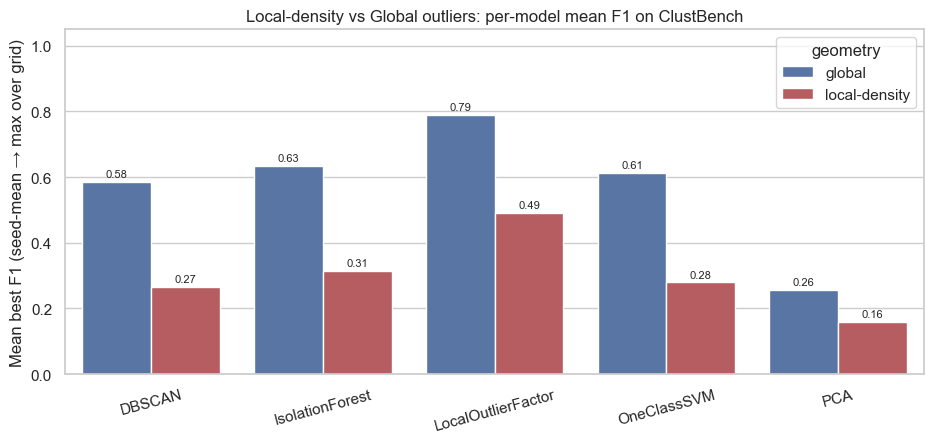

Per-model F1 gap between global and local-density geometries on ClustBench:


geometry,global,local-density,delta_global_minus_local
model,,,
OneClassSVM,0.614,0.279,0.334
IsolationForest,0.634,0.314,0.321
DBSCAN,0.584,0.266,0.319
LocalOutlierFactor,0.790,0.492,0.299
PCA,0.256,0.160,0.096



Weakest on local-density (density-aware needed) → PCA
Weakest on global (boundary/score-based)         → PCA


In [8]:
geometry_map = {
    "clustbench_compound": "local-density",
    "clustbench_fuzzyx": "local-density",
    "clustbench_zigzag_noisy": "local-density",
    "clustbench_ring_outliers": "global",
    "clustbench_ring_noisy": "global",
    "clustbench_hdbscan": "global",
}

best_per_dataset = (
    df_main.sort_values("f1_score", ascending=False)
    .groupby(["dataset", "model"], as_index=False)
    .head(1)
)

clust = best_per_dataset[best_per_dataset["dataset_group"] == "clustbench"].copy()
clust["geometry"] = clust["dataset"].map(geometry_map)
clust = clust.dropna(subset=["geometry"])

agg = (
    clust.groupby(["model", "geometry"], as_index=False)["f1_score"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg = agg.rename(columns={"mean": "mean_F1", "std": "std_F1", "count": "n_datasets"})
agg["std_F1"] = agg["std_F1"].fillna(0.0)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
sns.barplot(
    data=agg,
    x="model",
    y="mean_F1",
    hue="geometry",
    palette={"local-density": "#c44e52", "global": "#4c72b0"},
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
ax.set_ylabel("Mean best F1 (seed-mean → max over grid)")
ax.set_ylim(0, 1.05)
ax.set_title("Local-density vs Global outliers: per-model mean F1 on ClustBench")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(plots_dir / "local_vs_global_geometry.png", dpi=300, bbox_inches="tight")
plt.show()

gap = agg.pivot(index="model", columns="geometry", values="mean_F1").fillna(0.0)
if "global" in gap.columns and "local-density" in gap.columns:
    gap["delta_global_minus_local"] = gap["global"] - gap["local-density"]
    gap = gap.sort_values("delta_global_minus_local", ascending=False)

print("Per-model F1 gap between global and local-density geometries on ClustBench:")
display(gap.round(3))

if "delta_global_minus_local" in gap.columns:
    worst_local = gap.sort_values("local-density").index[0]
    worst_global = gap.sort_values("global").index[0]
    print(
        f"\nWeakest on local-density (density-aware needed) → {worst_local}\n"
        f"Weakest on global (boundary/score-based)         → {worst_global}"
    )

## Section 4: Discussion & Conclusions

This section summarizes **only** what appears in the notebook above: MLflow tables in Section 1, the five hyperparameter figures in Section 2, and the five robustness figures in Section 3. All F1 values use the same pipeline as the plots—**mean metric across random seeds for each hyperparameter tuple, then keep the best F1 per (dataset, model family)**.

### What Section 1 shows

**Leaderboards** (displayed after the heatmaps) average that best F1 over datasets separately for ODDS and ClustBench:

| Model | Mean best F1 (ODDS) | Mean best F1 (ClustBench) |
|---|---:|---:|
| IsolationForest | **0.40** | 0.47 |
| LocalOutlierFactor | 0.33 | **0.64** |
| DBSCAN | 0.34 | 0.43 |
| OneClassSVM | 0.33 | 0.45 |
| PCA | 0.33 | 0.21 |

Across all **24** benchmarks combined, mean best F1 orders as **IsolationForest (0.42)**, **LocalOutlierFactor (0.40)**, **DBSCAN (0.36)**, **OneClassSVM (0.36)**, **PCA (0.30)**.

**Per-dataset winner table** (code cell above): highest F1 among the five families on each dataset gives **LocalOutlierFactor 10**, **IsolationForest 7**, **DBSCAN 5**, **OneClassSVM 1**, **PCA 1**. **There is no single “best” detector**—only a best match to each benchmark.

**Heatmaps** (`heatmap_f1_score`, `heatmap_precision`, `heatmap_recall`, `heatmap_auc`): one best configuration per model × dataset. They are the right place to read **precision–recall trade-offs** (bright recall on one row often pairs with dim precision on the same row). **AUC** is missing for DBSCAN (no comparable continuous score in our pipeline). On ODDS averages from the leaderboard, **DBSCAN** has the highest mean recall (**0.66**) but the lowest mean precision (**0.34**); **IsolationForest** is the most balanced (**precision 0.44, recall 0.45**).

### What Section 2 shows (hyperparameter sensitivity)

| Model | Main takeaway |
|---|---|
| **OneClassSVM** | **OneClassSVM** quality depends on the **`nu`**; small `nu` is the worst. |
| **IsolationForest** | **IsolationForest**: **`contamination`** moves F1 strongly; **`n_estimators`** is a minor stabilizer. |
| **DBSCAN** | **DBSCAN**: **`eps`** dominates; smaller impact of **`min_samples`**. |
| **LocalOutlierFactor** | **LOF**: performance varies with **`n_neighbors`**. |
| **PCA** | **PCA**: higher **`n_components`** bring better performance. |

### What Section 3 shows (robustness)

| Figure | Main takeaway |
|---|---|
| `dimensionality impact` | No clear pattern. F1 varies significantly. |
| `best vs worst clustbench` | On **four** 2-D sets (`compound`, `ring_outliers`, `ring_noisy`, `hdbscan`), columns compare the **best** vs **worst** model family (by F1) against **ground truth**. Large gaps between families on the same row show that **family choice** matters more than fine tuning within a mismatched family. |
| `stability analysis` | Mean σ(F1) across seeds, hyperparameters, and datasets. **PCA** is the most stable across hyperparameters (lowest hyperparam bar); **DBSCAN** and **IsolationForest** show the largest hyperparameter spread in this run. High variance on different datasets showing importance of family selection on different datasets. |
| `n observations impact` | No clear pattern. F1 varies significantly. |
| `local vs global_geometry` | ClustBench datasets are **hand-labeled** as `local-density` (`compound`, `fuzzyx`, `zigzag_noisy`) vs `global` (`ring_outliers`, `ring_noisy`, `hdbscan`). Every family scores higher on the **global** trio in this run (Δ global − local ≈ **0.30–0.33** for IF, LOF, OCSVM, DBSCAN; **0.10** for PCA). |

### Strengths and weaknesses (tied to the figures above)

| Method | Strengths in this notebook | Weaknesses in this notebook |
|---|---|---|
| **IsolationForest** | Leads **ODDS** mean F1; **7** per-dataset wins; flattest **dimensionality** panel; competitive on **global** ClustBench bar (**0.63** mean F1 on global vs **0.31** on local-density). | Fewer ClustBench wins than LOF; **`contamination`** drives the IF heatmap. |
| **LocalOutlierFactor** | Leads **ClustBench** mean F1 (**0.64**); **10** per-dataset wins; highest **global** ClustBench bar means (**0.79** on global trio). | Lowest **ODDS** mean F1 among the top four (**0.33**); **`n_neighbors`** sensitivity in Section 2. |
| **OneClassSVM** | Mid-tier on ClustBench; benefits when `nu` and `gamma` sit in the hot region of `svm_nu_gamma.png`. | Weak **ODDS** F1; **nu–γ** cold corner; only **1** dataset win. |
| **DBSCAN** | **5** dataset wins; highest **ODDS** recall in the leaderboard. | Low **ODDS** precision/F1; **`eps`**-dominated heatmap; no AUC heatmap column; largest hyperparameter σ in `stability_analysis.png`. |
| **PCA** | Most **hyperparameter-stable** in `stability_analysis.png`; **0.80** mean ODDS AUC in the leaderboard despite lower F1. | Lowest overall mean F1 (**0.30**); weakest on ClustBench (**0.21**); **1** dataset win. |

### Conclusions

1. **Read the heatmaps and per-dataset winner table, not a single global rank.** LOF wins the most datasets; IF leads average ODDS F1; neither dominates everywhere.
2. **Tune threshold-like parameters first** (`contamination`, `nu`, `eps`, `n_components`)—Section 2 figures change more along those axes than along secondary hyperparameters.
3. **Expect high recall / lower precision from DBSCAN on ODDS** in this run.

Section 5 applies these ideas separately on `test_data.csv` (ensemble vote and `verification_vote_distribution.png`); it is not repeated here.


## Section 5: Verification Task (`test_data.csv`)

We predict anomaly labels for the unlabeled verification set using a **majority-voting ensemble** built from the best hyperparameter configuration of each base model discovered in Section 1. The pipeline is:

1. Load the raw CSV (drop the unnamed index column when present).
2. Standardize all features with `StandardScaler` (zero mean, unit variance) — the same preprocessing applied to every training dataset, which is required because LOF, OneClassSVM, DBSCAN, and PCA are all distance- or variance-sensitive.
3. For each of the five model families, recreate the best configuration (winning hyperparameters from MLflow on ODDS datasets) and fit it on the standardized verification features.
4. Cast every model's output to the unified binary convention `{0=inlier, 1=outlier}` and combine the votes with `EnsembleDetector.majority_vote` — a label is flagged as anomaly only when **more than half** of the base models agree.
5. Save the resulting labels to `test_labels.csv` with column `class`.


Winning hyperparameters per model (selected by mean F1 across ODDS datasets):


,params,mean_f1,min_f1,n_datasets,n_runs
model,,,,,
IsolationForest,"contamination=0.05, n_estimators=200",0.320,0.000,18,54
PCA,n_components=0.7,0.313,0.033,18,54
OneClassSVM,"nu=0.2, gamma=auto",0.253,0.028,18,18
LocalOutlierFactor,"n_neighbors=100, contamination=0.1",0.238,0.000,18,18
DBSCAN,"min_samples=20, eps=1.0",0.205,0.024,18,18


Loaded verification data: 3443 rows x 21 features
After StandardScaler: per-feature mean ≈ +4.01e-17, std ≈ 1.000
  IsolationForest        params={'contamination': 0.05, 'n_estimators': 200} -> 173 flagged of 3443 (5.0%)
  LocalOutlierFactor     params={'n_neighbors': 100, 'contamination': 0.1} -> 345 flagged of 3443 (10.0%)
  OneClassSVM            params={'nu': 0.2, 'gamma': 'auto'} -> 690 flagged of 3443 (20.0%)
  DBSCAN                 params={'min_samples': 20, 'eps': 1.0} -> 3443 flagged of 3443 (100.0%)
  PCA                    params={'n_components': 0.7} -> 345 flagged of 3443 (10.0%)

Dropping degenerate base predictors from the vote: DBSCAN. They flag 0 or all samples and would only add constant noise.
   Ensemble now votes across: IsolationForest, LocalOutlierFactor, OneClassSVM, PCA

Ensemble (majority of 4): 482 anomalies flagged (14.00% of 3443 samples)

Vote-count distribution across the 4 active base models:
# models agreeing
0    2628
1     333
2     300
3     108
4  

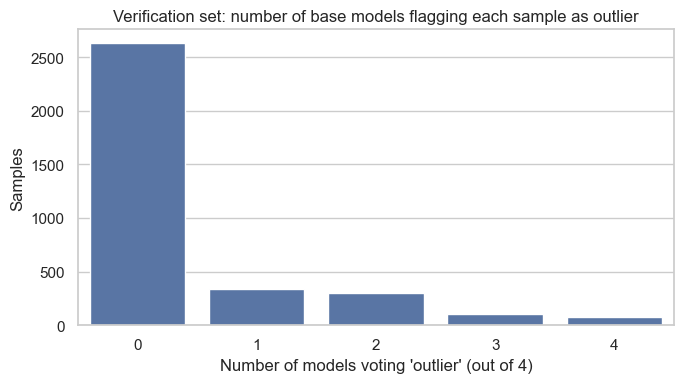

In [9]:
def _aggregate_best_params_per_model(
    runs_df: pd.DataFrame,
    metric: str = "f1_score",
    dataset_prefix: str = "odds_",
    seed_param: str = "params.random_state",
) -> pd.DataFrame:
    """Pick best hyperparameter config per model family (highest mean metric across datasets).

    We restrict to ODDS runs (real-world tabular data) because the verification set
    has 21 features — synthetic 2D ClustBench winners do not transfer to that geometry.
    Seeds are averaged out (i.e. a config is one row across all (dataset, seed) combinations).
    """
    df = runs_df.copy()
    df = df[df["dataset"].astype(str).str.startswith(dataset_prefix)]
    df = df.dropna(subset=[metric])
    if df.empty:
        return pd.DataFrame(
            columns=["model_key", "params", "mean_f1", "min_f1", "n_runs", "n_datasets"]
        )

    param_cols = [c for c in df.columns if c.startswith("params.") and c != seed_param]
    df["_params_key"] = (
        df[param_cols].astype(str).fillna("").agg("|".join, axis=1) if param_cols else ""
    )

    grouped = df.groupby(["model_key", "_params_key"], as_index=False).agg(
        mean_f1=(metric, "mean"),
        min_f1=(metric, "min"),
        n_runs=(metric, "size"),
        n_datasets=("dataset", pd.Series.nunique),
    )
    best = (
        grouped.sort_values("mean_f1", ascending=False).groupby("model_key", as_index=False).head(1)
    )

    records: list[dict[str, object]] = []
    for _, row in best.iterrows():
        sample = df[
            (df["model_key"] == row["model_key"]) & (df["_params_key"] == row["_params_key"])
        ].iloc[0]
        params: dict[str, object] = {}
        for col in param_cols:
            value = sample[col]
            if pd.isna(value):
                continue
            key = col.replace("params.", "")
            text = str(value)
            try:
                params[key] = int(text)
                continue
            except ValueError:
                pass
            try:
                params[key] = float(text)
                continue
            except ValueError:
                pass
            params[key] = text
        records.append(
            {
                "model_key": row["model_key"],
                "params": params,
                "mean_f1": row["mean_f1"],
                "min_f1": row["min_f1"],
                "n_runs": int(row["n_runs"]),
                "n_datasets": int(row["n_datasets"]),
            }
        )
    return pd.DataFrame.from_records(records)


runs_with_params = runs.copy()
runs_with_params["model_key"] = runs_with_params.get("tags.model_factory_key")
runs_with_params["dataset"] = runs_with_params.get("tags.dataset")
runs_with_params["f1_score"] = runs_with_params.get("metrics.f1_score")

best_params_df = _aggregate_best_params_per_model(runs_with_params, metric="f1_score")
best_params = {row["model_key"]: row["params"] for _, row in best_params_df.iterrows()}

best_params_display = best_params_df.copy()
best_params_display["model"] = best_params_display["model_key"].map(model_name_map)
best_params_display["mean_f1"] = best_params_display["mean_f1"].round(3)
best_params_display["min_f1"] = best_params_display["min_f1"].round(3)
best_params_display["params"] = best_params_display["params"].apply(
    lambda p: ", ".join(f"{k}={v}" for k, v in p.items())
)
best_params_display = best_params_display.set_index("model").sort_values(
    "mean_f1", ascending=False
)[["params", "mean_f1", "min_f1", "n_datasets", "n_runs"]]
print("Winning hyperparameters per model (selected by mean F1 across ODDS datasets):")
display(best_params_display)

test_csv_path = Path("data/test_data.csv")
test_raw = pd.read_csv(test_csv_path)
if test_raw.columns[0] == "" or test_raw.columns[0].lower().startswith("unnamed"):
    test_raw = test_raw.iloc[:, 1:]
test_features_raw = test_raw.to_numpy()
print(
    f"Loaded verification data: {test_features_raw.shape[0]} rows x "
    f"{test_features_raw.shape[1]} features"
)

scaler = StandardScaler()
test_features = scaler.fit_transform(test_features_raw)
print(
    f"After StandardScaler: per-feature mean ≈ {test_features.mean(axis=0).mean():+.2e}, "
    f"std ≈ {test_features.std(axis=0).mean():.3f}"
)


def _predict_for_verification(
    model_key: str, params: dict[str, object], features: np.ndarray
) -> np.ndarray:
    """Fit a base model on the verification data and return 0/1 predictions.

    Special-case LOF to use ``novelty=False`` + ``fit_predict`` because that is the
    correct sklearn pattern when fit and predict are on the same dataset.
    """
    spec = AnomalyDetectorFactory.create(model_key)
    model = clone(spec.model)
    if model_key == "local_outlier_factor":
        model.set_params(novelty=False)
    filtered = {k: v for k, v in params.items() if k in model.get_params()}
    if filtered:
        model.set_params(**filtered)

    if model_key == "local_outlier_factor":
        return _normalize_labels(model.fit_predict(features))
    model.fit(features)
    return _predict_outliers(model, features)


ensemble_votes: list[np.ndarray] = []
ensemble_names: list[str] = []
ensemble_summary: list[dict[str, object]] = []
for model_key in ["isolation_forest", "local_outlier_factor", "one_class_svm", "dbscan", "pca"]:
    params = best_params.get(model_key, {})
    preds = _predict_for_verification(model_key, params, test_features)
    ensemble_votes.append(preds.astype(int))
    ensemble_names.append(model_name_map[model_key])
    flagged = int(preds.sum())
    pct = 100 * flagged / len(preds)
    ensemble_summary.append(
        {
            "model": model_name_map[model_key],
            "params": params,
            "flagged": flagged,
            "pct": round(pct, 2),
        }
    )
    print(
        f"  {model_name_map[model_key]:<22} params={params} -> {flagged} flagged "
        f"of {len(preds)} ({pct:.1f}%)"
    )

degenerate_idx = [i for i, v in enumerate(ensemble_votes) if int(v.sum()) in (0, len(v))]
non_degenerate_votes = [v for i, v in enumerate(ensemble_votes) if i not in degenerate_idx]
non_degenerate_names = [n for i, n in enumerate(ensemble_names) if i not in degenerate_idx]
if degenerate_idx and len(non_degenerate_votes) >= 2:
    dropped = ", ".join(ensemble_names[i] for i in degenerate_idx)
    print(
        f"\nDropping degenerate base predictors from the vote: {dropped}. "
        f"They flag 0 or all samples and would only add constant noise."
    )
    print(f"   Ensemble now votes across: {', '.join(non_degenerate_names)}")
    ensemble_used = non_degenerate_votes
    ensemble_used_names = non_degenerate_names
elif degenerate_idx:
    print("\n⚠ Too few non-degenerate base predictors to drop; keeping all in the vote.")
    ensemble_used = ensemble_votes
    ensemble_used_names = ensemble_names
else:
    print("\nAll base predictors produce non-trivial predictions.")
    ensemble_used = ensemble_votes
    ensemble_used_names = ensemble_names

ensemble = EnsembleDetector()
final_labels = ensemble.majority_vote(ensemble_used)
vote_matrix = np.vstack(ensemble_used)
vote_counts = vote_matrix.sum(axis=0)

n_voters = len(ensemble_used)
print(
    f"\nEnsemble (majority of {n_voters}): "
    f"{int(final_labels.sum())} anomalies flagged "
    f"({final_labels.mean() * 100:.2f}% of {len(final_labels)} samples)"
)

vote_dist = (
    pd.Series(vote_counts)
    .value_counts()
    .sort_index()
    .rename_axis("# models agreeing")
    .rename("samples")
)
print(f"\nVote-count distribution across the {n_voters} active base models:")
print(vote_dist.to_string())

output_path = Path("test_labels.csv")
pd.DataFrame({"class": final_labels.astype(int)}).to_csv(output_path, index=False)

plt.figure(figsize=(7, 4))
sns.countplot(x=vote_counts, color="#4c72b0")
plt.title("Verification set: number of base models flagging each sample as outlier")
plt.xlabel(f"Number of models voting 'outlier' (out of {n_voters})")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig(plots_dir / "verification_vote_distribution.png", dpi=300)
plt.show()

### Justification of the ensemble design

**Why an ensemble (majority voting)?** Section 4 showed that the five base methods fail in *different* ways — IsolationForest and PCA miss local anomalies, LOF and DBSCAN are brittle on high-dimensional or large-`n` data, OneClassSVM depends critically on `nu`/`gamma`. Their individual failures might be an ideal setting for a vote-based ensemble: the chance that all five methods agree on a *wrong* label is much lower than the chance any one of them is wrong alone. Hard majority voting (rather than score averaging) is the natural choice here because the methods produce predictions on different scales — a `LOF` factor, an `OCSVM` margin, a `PCA` reconstruction error, an `IsolationForest` path length, and a `DBSCAN` cluster id are not directly comparable, so reducing them to a binary vote before combining is the most defensible aggregation.

We additionally apply a **degenerate-predictor guard**: any base model that flags 0 or all samples on the verification set is dropped from the vote, since a constant predictor carries no information and would only bias the voting threshold. 

**Why this exact combination of methods?** The five chosen detectors cover the three complementary "views" of an anomaly identified in Section 4:

- **Isolation view** — `IsolationForest` (random axis-aligned cuts; strong at global anomalies in high dimensions).
- **Density view** — `LocalOutlierFactor` and `DBSCAN` (sensitive to local density variations that the other methods cannot see).
- **Reconstruction / boundary view** — `PCA` (linear subspace) and `OneClassSVM` (non-linear kernel boundary).

Each view contributes signal the others lack when it is not degenerate on the verification set.

**Why these hyperparameters?** Each base configuration is the one with the highest *mean F1 across the ODDS benchmarks*, averaging over seeds. This is deliberately different from picking the absolute single-best run from the entire sweep:

- An "absolute best" config typically wins on one specific 2D synthetic dataset and then breaks on the 21-feature verification set. Mean-F1 selection over ODDS picks configurations that have to work *across* tabular datasets of varying dimensionality, so the chosen `eps`, `n_neighbors`, etc. are more likely to transfer to the verification set's geometry.
- We restrict the selection to ODDS only because every ClustBench dataset is two-dimensional and synthetic, with anomaly geometries (rings, clusters of different density) that do not resemble `test_data.csv`. Mixing those into the selection averages biases parameters toward 2D scales.

**Why this preprocessing?** Four of the five base methods are distance- or variance-sensitive (LOF, OneClassSVM with RBF kernel, DBSCAN with Euclidean `eps`, and PCA). Without a common scale, features with larger numerical range would dominate the distance metric and silently break those detectors. `StandardScaler` (zero mean, unit variance per feature) is the exact preprocessing applied during the training of every benchmark run, which is essential for the winning hyperparameters to remain valid: an `eps` tuned on standardized data must be applied to standardized data. We deliberately do **not** apply more aggressive transforms (PCA-whitening, log, winsorization) because those would change the geometry the base models were tuned on, and because the test data is unlabeled — we have no way to validate that such transforms preserve the anomaly signal.

The final predictions are written to `test_labels.csv` with a single column `class` (`1 = outlier`, `0 = inlier`), as required by the task.
